In [6]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os



In [7]:
import torch
import torchvision
from torch.utils.data import DataLoader,random_split
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torchvision.transforms import ToTensor
import torchvision.transforms as T


In [8]:
data_dir='/kaggle/input/cassava-leaf-disease-classification/train_images'
label_dir='/kaggle/input/cassava-leaf-disease-classification/train.csv'

In [9]:
from torch.utils.data import dataset
import os

files=os.listdir(data_dir)

In [10]:
len(files)

21397

In [11]:
files[1]

'1215607589.jpg'

In [12]:
df=pd.read_csv(label_dir)
df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [13]:
def open_image(path):
    with open(path,'rb') as f:
        img=Image.open(f)
        return img.convert('RGB')

In [14]:
from torch.utils.data import Dataset
class CassavaLeaf(Dataset):
    def __init__(self,root,transform):
        super().__init__()
        self.root=root
        self.files=[fname for fname in os.listdir(root) if fname.endswith('jpg')]
        self.classes=df.iloc[:,1]
        self.transform=transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self,i):
        fname=self.files[i]
        fpath=os.path.join(self.root,fname)
        img=self.transform(open_image(fpath))
        class_idx=self.classes[i]
        return img,class_idx

In [15]:
imagenet_stats=([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

image_size=120
dataset=CassavaLeaf(data_dir,T.Compose([T.Resize(image_size),
                                       T.Pad(8,padding_mode='reflect'),
                                       T.RandomCrop(image_size),
                                       T.ToTensor(),
                                       T.Normalize(*imagenet_stats)]))

In [16]:
len(dataset)

21397

In [17]:
train_ds,val_ds=random_split(dataset,[20000,1397])


In [18]:
train_dl=DataLoader(train_ds,batch_size=20,shuffle=True,num_workers=3,pin_memory=True)
val_dl=DataLoader(val_ds,batch_size=20,num_workers=3,pin_memory=True)

In [19]:
import json

json_file = open('/kaggle/input/cassava-leaf-disease-classification/label_num_to_disease_map.json')
classes_name = json.load(json_file)
classes_name

{'0': 'Cassava Bacterial Blight (CBB)',
 '1': 'Cassava Brown Streak Disease (CBSD)',
 '2': 'Cassava Green Mottle (CGM)',
 '3': 'Cassava Mosaic Disease (CMD)',
 '4': 'Healthy'}

In [20]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

def denormalize(image,mean,std):
    # if len(image.shape)==3:
        image=image.unsqueeze(0)
        mean=torch.tensor(mean).reshape(1,3,1,1)
        std=torch.tensor(std).reshape(1,3,1,1)
        return image *std+mean

def show_image(img_tensor,label):
  print('label : ',classes_name[str(label)],'('+str(label)+')')
  img_tensor=denormalize(img_tensor,*imagenet_stats)[0].permute((1,2,0))
  plt.imshow(img_tensor)

label :  Cassava Bacterial Blight (CBB) (0)


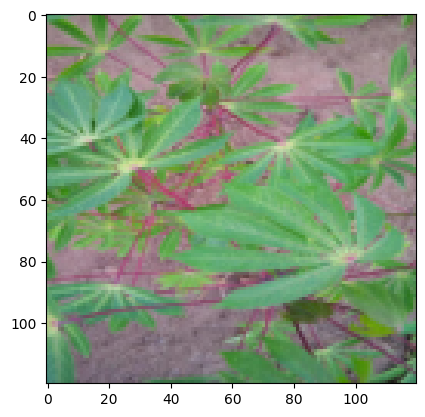

In [21]:
show_image(*dataset[0])

torch.Size([20, 3, 120, 120])


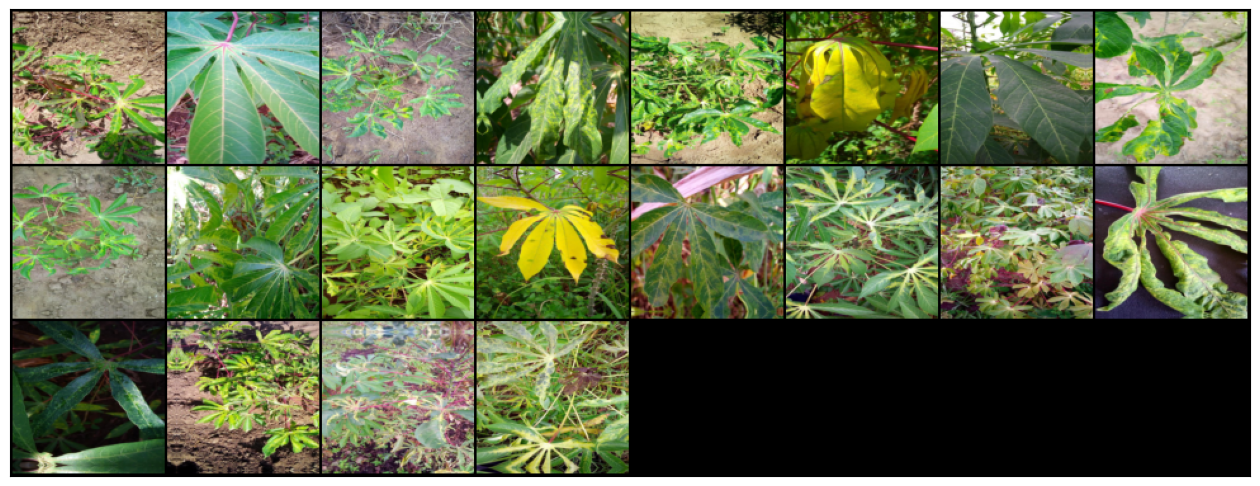

In [22]:
from torchvision.utils import make_grid

def show_batch(dl):
  for image,label in dl:
    print(image.shape)
      
    fig,ax=plt.subplots(figsize=(16,16))
    ax.set_xticks([]);ax.set_yticks([])
    image=denormalize(image[:64],*imagenet_stats)
    # print(image[0].shape)
    ax.imshow(make_grid(image[0],nrow=8).permute(1,2,0))
    break

show_batch(train_dl)

In [23]:
def accuracy(output,label):
    _,pred=torch.max(output,dim=1)
    return torch.tensor(torch.sum(pred==label).item()/len(pred))

class ImageClassifierBase(nn.Module):
    def training_step(self,batch):
        image,label=batch
        out=self(image)
        loss=F.cross_entropy(out,label)
        return loss

    def validation_step(self,batch):
        image,label=batch
        out=self(image)
        val_loss=F.cross_entropy(out,label)
        val_acc=accuracy(out,label)
        return {'val_loss':val_loss,'val_acc':val_acc}

    def validation_epoch_end(self,output):
         batch_loss=[x['val_loss'] for x in output]
         epoch_loss=torch.stack(batch_loss).mean()
         batch_acc=[x['val_acc'] for x in output]
         epoch_acc=torch.stack(batch_acc).mean()
         return {'val_loss':epoch_loss.item(),'val_acc':epoch_acc.item()}

    def epoch_end(self,epoch,result):
        print("Epoch [{}],{} train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, "last_lr: {:.5f},".format(result['lrs'][-1]) if 'lrs' in result else '',
            result['train_loss'], result['val_loss'], result['val_acc']))

    
    @torch.no_grad()
    def evaluate(self,val_loader):
         self.eval()
         output=[self.validation_step(batch) for batch in val_loader]
         return self.validation_epoch_end(output)

In [24]:
from torchvision import models

#models.list_models()

class CassavaModel(ImageClassifierBase):
    def __init__(self,num_classes,pretrained=True):
        super().__init__()
        self.network=models.resnet50(pretrained=pretrained)
        self.network.fc=nn.Linear(self.network.fc.in_features,num_classes)

    def forward(self,xb):
        return self.network(xb)

In [25]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data,device):
    if isinstance(data,(list,tuple)):
        return [to_device(x,device) for x in data]
    return data.to(device,non_blocking=True)

In [26]:
class DeviceDataLoader():
    def __init__(self,dl,device):
        self.dl=dl
        self.device=device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b,self.device)

    def __len__(self):
        return len(self.dl)

In [27]:
from tqdm.notebook import tqdm

def fit(epochs,lr,model,train_dl,val_dl,opt_fn=torch.optim.SGD):
    history=[]
    opt=opt_fn(model.parameter(),lr)

    for epoch in range(epochs):
        model.train()
        train_losses=[]

        for batch in tqdm(train_dl):
            loss=model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            opt.step()
            opt.zero_grad()
        result=model.evaluate(val_dl)
        result['train_loss']=torch.stack(train_losses).mean().item()
        model.epoch(epoch,result)
        history.append(result)
    return history

In [28]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def fit_one_cycle(epochs,mox_lr,model,train_dl,val_dl,weight_decay=0,
                  grad_clip=None, opt_func=torch.optim.SGD):
    torch.cuda.empty_cache()
    history=[]
    optimizer=opt_func(model.parameters(),max_lr,weight_decay=weight_decay)

    sched=torch.optim.lr_scheduler.OneCycleLR(optimizer,max_lr,epochs=epochs,
                                             steps_per_epoch=len(train_dl))

    for epoch in range(epochs):
        model.train()
        train_losses=[]
        lrs=[]
        for batch in tqdm(train_dl):
            loss=model.training_step(batch)
            train_losses.append(loss)
            loss.backward()

            if grad_clip:
                nn.utils.clip_grad_value_(model.parameters(),grad_clip)

            optimizer.step()
            optimizer.zero_grad()
            lrs.append(get_lr(optimizer))
            sched.step()
        result=model.evaluate(val_dl)
        result['train_loss']=torch.stack(train_losses).mean().item()
        result['lrs']=lrs
        model.epoch_end(epoch,result)
        history.append(result)
    return history
            

In [29]:
device=get_default_device()
device

device(type='cuda')

In [30]:
train_dl=DeviceDataLoader(train_dl,device)
val_dl=DeviceDataLoader(val_dl,device)

In [31]:
model=CassavaModel(len(dataset.classes))

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s] 


In [32]:
to_device(model, device);

In [33]:
history=[model.evaluate(val_dl)]


In [34]:
history

[{'val_loss': 10.015494346618652, 'val_acc': 0.0}]

In [35]:
epochs = 6
max_lr = 0.01
grad_clip = 0.1
weight_decay = 1e-4
opt_func = torch.optim.Adam

In [36]:
history += fit_one_cycle(epochs, max_lr, model, train_dl, val_dl,
                         grad_clip=grad_clip,
                         weight_decay=weight_decay,
                         opt_func=opt_func)

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [0],last_lr: 0.00603, train_loss: 1.3392, val_loss: 1.3341, val_acc: 0.6221


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [1],last_lr: 0.00994, train_loss: 1.2499, val_loss: 1.2244, val_acc: 0.6221


  0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch [3],last_lr: 0.00463, train_loss: 1.2133, val_loss: 1.2471, val_acc: 0.6221


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [4],last_lr: 0.00133, train_loss: 1.2000, val_loss: 1.1961, val_acc: 0.6221


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch [5],last_lr: 0.00000, train_loss: 1.1877, val_loss: 1.1786, val_acc: 0.6221


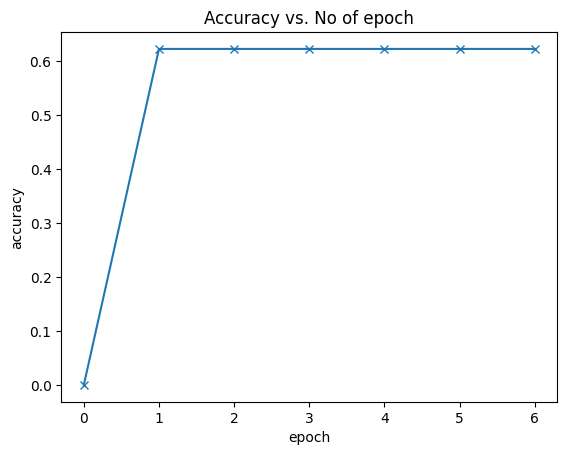

In [43]:
def plot_accuracies(history):
    accuracies=[x['val_acc'] for x in history]
    plt.plot(accuracies,'-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No of epoch');


plot_accuracies(history)

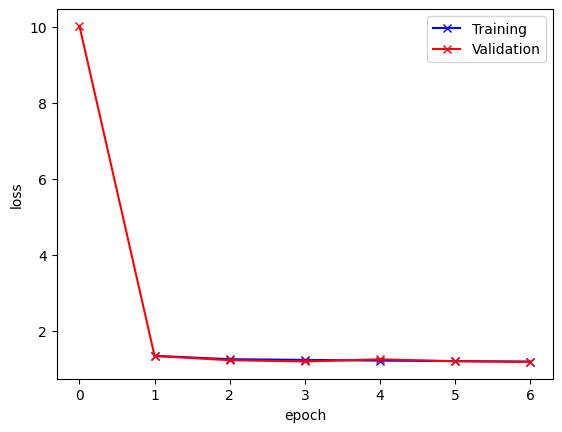

In [44]:
def plot_losses(history):
  train_losses= [x.get('train_loss') for x in history]
  val_losses=[x['val_loss'] for x in history]
  plt.plot(train_losses,'-bx')
  plt.plot(val_losses,'-rx')
  plt.xlabel('epoch')
  plt.ylabel('loss')
  plt.legend(['Training','Validation'])


plot_losses(history)

In [46]:
torch.save(model.state_dict(), 'cassava_leaf_clssification')


In [52]:
def predict_image(img,model):
    xb=to_device(img.unsqueeze(0),device)
    yb=model(xb)
    _,preds=torch.max(yb,dim=1)
    return classes_name[str(preds[0].item())]

In [54]:
classes_name

{'0': 'Cassava Bacterial Blight (CBB)',
 '1': 'Cassava Brown Streak Disease (CBSD)',
 '2': 'Cassava Green Mottle (CGM)',
 '3': 'Cassava Mosaic Disease (CMD)',
 '4': 'Healthy'}

Label Cassava Mosaic Disease (CMD) predicted: Cassava Mosaic Disease (CMD)


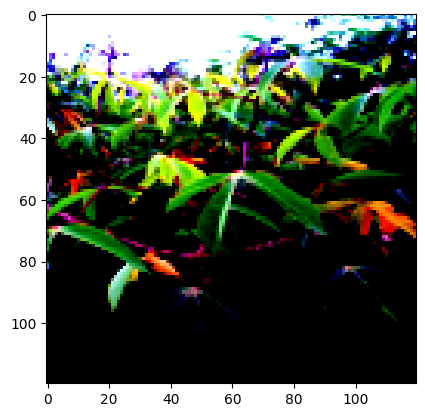

In [55]:
img,label=val_ds[1]
plt.imshow(img.permute(1,2,0).clamp(0,1))
print('Label',classes_name[str(label)],"predicted:",predict_image(img,model))